# Range-Doppler Heatmap Analysis and CNN-LSTM Pipeline

This single, self-contained notebook loads the range-Doppler data files, visualizes robust
range-Doppler signatures for each activity, builds a hybrid CNN-LSTM model, and provides
a short training/evaluation pipeline. The notebook is written in a standard, reproducible
style: clear contract, assumptions, data loading, preprocessing, visualization, model,
training/evaluation, and saving.

Notes:
- No automatic package installation is performed in this notebook. If PyTorch is not
  available in your environment the model/training cells will be skipped and a clear
  message will appear.
- If visualizations look incorrect, run the file-listing cell and paste a small sample of
  one `range_doppler.csv` (header + 3 rows) so the parser can be adapted.

## Contract / Goals
- Input: directory tree containing activity subfolders with `range_doppler` CSV files (one row per frame or per timestamp).
- Output: per-activity representative visualizations (mean/std heatmaps) and a working CNN-LSTM training stub.
- Success criteria: we can load heatmaps, show clear per-activity patterns, and run a short model forward/backward pass when PyTorch is available.

In [29]:
# Cell 1: standard imports and environment check
from pathlib import Path
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

WORKDIR = Path('.').resolve()
print('Notebook working dir:', WORKDIR)

# Try import torch but do not install anything automatically
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
    print('PyTorch available:', torch.__version__)
except Exception as _e:
    TORCH_AVAILABLE = False
    print('PyTorch not available in this environment. Model/training cells will be skipped.')

Notebook working dir: C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\process_heatmaps
PyTorch available: 2.9.0+cpu


In [30]:
# Cell 2: data discovery utilities
from pathlib import Path

def list_candidate_files(root_dir: Path):
    root_dir = Path(root_dir)
    files = []
    for p in root_dir.rglob('*.csv'):
        name = p.name.lower()
        if 'range' in name or 'doppler' in name or 'rd' in name:
            files.append(p)
    return sorted(files)


def try_read_csv_head(path: Path, nrows: int = 5):
    try:
        df = pd.read_csv(path, nrows=nrows)
    except Exception:
        try:
            df = pd.read_table(path, nrows=nrows)
        except Exception as e:
            print('Could not read', path, '->', e)
            return None
    return df

# Point this to the folder that contains activity subfolders (adjust if needed)
DATA_ROOT = WORKDIR.parent  # assume notebook inside process_heatmaps subfolder
print('Assumed dataset root:', DATA_ROOT)
candidates = list_candidate_files(DATA_ROOT)
print('Candidate CSVs found (first 20):')
for p in candidates[:20]:
    print('-', p)

# if there are no candidates, show top-level directories for the user to inspect
if len(candidates) == 0:
    print('\nNo candidate range-Doppler CSVs found under DATA_ROOT. Please confirm where your CSV files live and update DATA_ROOT.')

# show columns of the first candidate (if any)
if len(candidates) > 0:
    head = try_read_csv_head(candidates[0])
    if head is not None:
        print('\nSample file:', candidates[0])
        display(head)

Assumed dataset root: C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity
Candidate CSVs found (first 20):
- C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Approach\range_doppler.csv
- C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Sitting\range_doppler.csv
- C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Splitting\range_doppler.csv
- C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Standing\range_doppler.csv
- C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Walking\range_doppler.csv

Sample file: C:\Users\1405

,timestamp,frame_number,range_bin,doppler_bin,signal_strength
0,2025-10-10 01:35:51.568,1,0,0,5179
1,2025-10-10 01:35:51.568,1,0,1,4928
2,2025-10-10 01:35:51.568,1,0,2,3012
3,2025-10-10 01:35:51.568,1,0,3,2574
4,2025-10-10 01:35:51.568,1,0,4,2617


In [31]:
# Cell 3: robust parser for a heatmap stored in a DataFrame row or long-form file
# This parser handles:
# - wide format: JSON array string in a column named 'range_doppler','doppz','heatmap','rd_matrix'
# - flattened numeric string with commas or spaces
# - numeric columns that collectively represent a flattened heatmap
# - long (tidy) format: rows with (frame_number, range_bin, doppler_bin, signal_strength)
# The parser returns a 2D numpy array (range_bins x doppler_bins) or None.

def infer_shape_from_len(L, hints=((16,256),(128,64),(64,128),(32,64))):
    for h,w in hints:
        if h*w == L:
            return (h,w)
    # fallback to nearest factors around sqrt
    s = int(math.sqrt(L))
    for a in range(s,0,-1):
        if L % a == 0:
            return (a, L//a)
    return (L,1)


def parse_heatmap_from_df_row(row, hints=((16,256),(128,64),(64,128),(32,64))):
    # 1) look for known column names that contain an encoded matrix
    for col in ('range_doppler','doppz','heatmap','rd_matrix'):
        if col in row.index:
            val = row[col]
            # if JSON-like string
            if isinstance(val, str) and val.strip().startswith('['):
                try:
                    arr = json.loads(val)
                    arr = np.array(arr)
                except Exception:
                    arr = None
            else:
                arr = np.array(val)
            if arr is None:
                continue
            if arr.ndim == 2:
                return arr
            if arr.ndim == 1:
                h,w = infer_shape_from_len(arr.size, hints)
                return arr.reshape(h,w)
    # 2) look for any string column that looks like a flattened numeric list
    for val in row.values:
        if isinstance(val, str) and (',' in val or ' ' in val) and any(ch.isdigit() for ch in val):
            # try split by comma then space
            s = val.strip()
            if s.startswith('[') and s.endswith(']'):
                s = s[1:-1]
            parts = [p for p in (s.replace(',', ' ').split()) if p!='']
            try:
                nums = np.array([float(x) for x in parts], dtype=np.float32)
            except Exception:
                nums = None
            if nums is None:
                continue
            h,w = infer_shape_from_len(nums.size, hints)
            return nums.reshape(h,w)
    # 3) numeric columns fallback: collect numeric values in the row in order
    numeric_vals = [v for v in row.values if isinstance(v, (int, float, np.integer, np.floating))]
    if len(numeric_vals) > 1:
        nums = np.array(numeric_vals, dtype=np.float32)
        h,w = infer_shape_from_len(nums.size, hints)
        return nums.reshape(h,w)
    return None


def load_heatmaps_from_longform(df, frame_col='frame_number', rcol='range_bin', dcol='doppler_bin', valcol='signal_strength', max_frames=None):
    """Given a long-form DataFrame with one row per (frame, range_bin, doppler_bin),
    reconstruct a list of 2D heatmaps ordered by frame_number.
    """
    if frame_col not in df.columns or rcol not in df.columns or dcol not in df.columns or valcol not in df.columns:
        return None
    # compute grid size
    max_r = int(df[rcol].max())
    max_d = int(df[dcol].max())
    R = max_r + 1
    D = max_d + 1
    heatmaps = []
    grouped = df.groupby(frame_col)
    frames = sorted(grouped.groups.keys())
    if max_frames is not None:
        frames = frames[:max_frames]
    for f in frames:
        sub = grouped.get_group(f)
        # create zero matrix and fill
        mat = np.zeros((R, D), dtype=np.float32)
        mat[sub[rcol].to_numpy().astype(int), sub[dcol].to_numpy().astype(int)] = sub[valcol].to_numpy().astype(np.float32)
        heatmaps.append(mat)
    return heatmaps

# Quick internal test (only runs if a candidate file exists): show how first row/file is parsed
if len(candidates) > 0:
    p = candidates[0]
    try:
        df = pd.read_csv(p, nrows=50)
    except Exception:
        df = pd.read_table(p, nrows=50)
    print('Parsing preview for:', p)
    # if longform
    if set(('frame_number','range_bin','doppler_bin','signal_strength')).issubset(df.columns):
        hms = load_heatmaps_from_longform(pd.read_csv(p), max_frames=3)
        print('Detected long-form. Produced heatmaps:', None if hms is None else [h.shape for h in hms])
    else:
        for i, row in df.iterrows():
            hm = parse_heatmap_from_df_row(row)
            print(' row', i, '-> parsed heatmap:', None if hm is None else hm.shape)

Parsing preview for: C:\Users\14052\Desktop\Research\Research\3D_People_tracking\Github\TI_6843\Fall 25\Data\Social Exp Data\Dataset 2\Group Activity\Approach\range_doppler.csv
Detected long-form. Produced heatmaps: [(64, 128), (64, 128), (64, 128)]
Detected long-form. Produced heatmaps: [(64, 128), (64, 128), (64, 128)]


In [32]:
# Cell 4: build sequence dataset (std/mean-based representations)
class RangeDopplerSequenceDataset:
    def __init__(self, root_dir, seq_len=8, stride=1, max_per_file=1000):
        self.root = Path(root_dir)
        self.seq_len = seq_len
        self.stride = stride
        self.samples = []  # list of (seq (T,H,W), label)
        self.labels = []
        self._index_files(max_per_file)
    def _index_files(self, max_per_file):
        for activity_dir in sorted(self.root.iterdir()):
            if not activity_dir.is_dir():
                continue
            files = [p for p in activity_dir.glob('*.csv') if 'range' in p.name.lower() or 'doppler' in p.name.lower()]
            if not files:
                continue
            for f in files:
                try:
                    df = pd.read_csv(f)
                except Exception:
                    df = pd.read_table(f)
                heatmaps = []
                # If file appears long-form (one row per cell), reconstruct heatmaps per frame
                if set(('frame_number','range_bin','doppler_bin','signal_strength')).issubset(df.columns):
                    long_hms = load_heatmaps_from_longform(df, max_frames=max_per_file)
                    if long_hms is not None:
                        heatmaps = long_hms
                else:
                    for _, row in df.iterrows():
                        hm = parse_heatmap_from_df_row(row)
                        if hm is not None:
                            heatmaps.append(hm.astype(np.float32))
                            if len(heatmaps) >= max_per_file:
                                break
                if len(heatmaps) < self.seq_len:
                    continue
                for start in range(0, len(heatmaps) - self.seq_len + 1, self.stride):
                    seq = np.stack(heatmaps[start:start+self.seq_len], axis=0)
                    self.samples.append((seq, activity_dir.name))
                    if activity_dir.name not in self.labels:
                        self.labels.append(activity_dir.name)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        seq, label = self.samples[idx]
        seq = (seq - seq.mean()) / (seq.std() + 1e-6)
        return seq, self.labels.index(label)
    def get_label_names(self):
        return self.labels

# create dataset using the assumed DATA_ROOT (parent of notebook folder)
DATASET_ROOT = DATA_ROOT
ds = RangeDopplerSequenceDataset(DATASET_ROOT, seq_len=8, stride=2)
print('Sequences indexed:', len(ds))
print('Labels:', ds.get_label_names())

Sequences indexed: 184
Labels: ['Approach', 'Sitting', 'Splitting', 'Standing', 'Walking']


Activities with computed summaries: ['Approach', 'Sitting', 'Splitting', 'Standing', 'Walking']


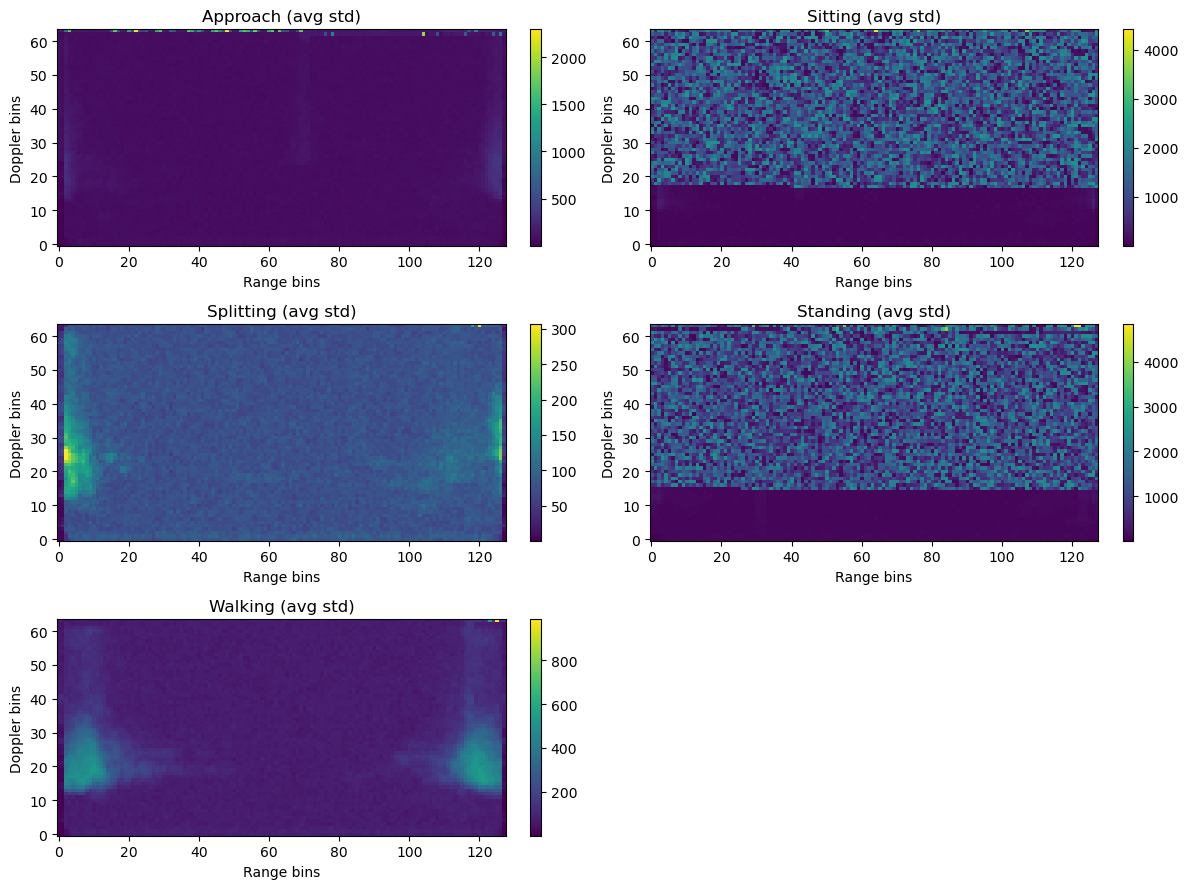

In [33]:
# Cell 5: Visualization per activity - std over time as representative heatmap
from matplotlib.colors import Normalize

def activity_summary_heatmaps(dataset):
    # compute per-sample std across time (T axis) -> (H,W) per sample. Then average per activity.
    sums = defaultdict(lambda: None)
    counts = defaultdict(int)
    for i in range(len(dataset)):
        seq, lbl = dataset.samples[i]
        label_name = dataset.samples[i][1]
        # seq is T,H,W
        stdmap = np.std(seq, axis=0)
        if sums[label_name] is None:
            sums[label_name] = stdmap.astype(np.float64)
        else:
            sums[label_name] += stdmap
        counts[label_name] += 1
    # average and return
    result = {}
    for k,v in sums.items():
        result[k] = v / counts[k]
    return result

summaries = activity_summary_heatmaps(ds)
print('Activities with computed summaries:', list(summaries.keys()))

# plot summaries in a grid
n = len(summaries)
cols = 2
rows = (n + cols - 1) // cols
fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 3*rows))
axs = axs.flatten() if n>1 else [axs]
for i,(k,v) in enumerate(sorted(summaries.items())):
    im = axs[i].imshow(v, aspect='auto', origin='lower', cmap='viridis')
    axs[i].set_title(f'{k} (avg std)')
    axs[i].set_xlabel('Range bins')
    axs[i].set_ylabel('Doppler bins')
    fig.colorbar(im, ax=axs[i], fraction=0.03)
# hide unused axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')
plt.tight_layout()
plt.show()

In [34]:
# Cell 6: Model definition (standard, readable) - only if torch is available
if TORCH_AVAILABLE:
    class CNNEncoder(nn.Module):
        def __init__(self, in_ch=1, emb_dim=256):
            super().__init__()
            self.enc = nn.Sequential(
                nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, 3, padding=1, stride=2), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 96, 3, padding=1, stride=2), nn.BatchNorm2d(96), nn.ReLU(),
                nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(96, emb_dim), nn.ReLU()
            )
        def forward(self, x):
            return self.enc(x)

    class CNNLSTM(nn.Module):
        def __init__(self, emb_dim=256, hidden=128, n_classes=10):
            super().__init__()
            self.cnn = CNNEncoder(in_ch=1, emb_dim=emb_dim)
            self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True)
            self.head = nn.Sequential(nn.Linear(hidden, 128), nn.ReLU(), nn.Linear(128, n_classes))
        def forward(self, x):
            # x: B,T,H,W or B,T,1,H,W
            if x.dim() == 4:
                x = x.unsqueeze(2)
            B,T,C,H,W = x.shape
            x = x.view(B*T, C, H, W)
            emb = self.cnn(x)
            emb = emb.view(B, T, -1)
            out, _ = self.lstm(emb)
            out = out[:, -1, :]
            return self.head(out)
else:
    print('Torch not available - model cells skipped.')

In [35]:
# Cell 7: Training stub and quick run (safe defaults)
if TORCH_AVAILABLE and len(ds) > 0:
    # create a minimal torch Dataset and DataLoader for quick sanity training
    from torch.utils.data import Dataset, DataLoader
    class TorchRangeDataset(Dataset):
        def __init__(self, seq_samples):
            self.samples = seq_samples
        def __len__(self):
            return len(self.samples)
        def __getitem__(self, idx):
            seq, lbl = self.samples[idx]
            # seq: T,H,W -> torch expects C,H,W, so we leave batch as B,T,H,W and add channel later
            return seq, lbl
    # take a small subset for a quick smoke test
    quick_idx = list(range(min(128, len(ds))))
    quick_samples = [ (ds.samples[i][0], ds.labels.index(ds.samples[i][1])) for i in quick_idx ]
    td = TorchRangeDataset(quick_samples)
    def collate(batch):
        seqs = np.stack([b[0] for b in batch], axis=0)  # B,T,H,W
        seqs = torch.from_numpy(seqs).float()
        # add channel dim -> B,T,1,H,W handled in model
        labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
        return seqs, labels
    loader = DataLoader(td, batch_size=8, shuffle=True, collate_fn=collate)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CNNLSTM(n_classes=len(ds.get_label_names())).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(1):
        total = 0
        correct = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            preds = logits.argmax(dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()
        print(f'Epoch quick-run: accuracy={correct/total:.3f}, loss={loss.item():.4f}')
    # save a small checkpoint
    ckpt = { 'model_state': model.state_dict(), 'labels': ds.get_label_names() }
    torch.save(ckpt, 'quick_checkpoint.pth')
    print('Saved quick_checkpoint.pth')
else:
    if not TORCH_AVAILABLE:
        print('Skipping training: PyTorch not available in this environment.')
    elif len(ds) == 0:
        print('Skipping training: no sequences indexed. See previous cells to list candidate CSVs.')

Epoch quick-run: accuracy=0.281, loss=1.4234
Saved quick_checkpoint.pth


N samples: 184, train: 147, val: 37
Epoch 1/5: train_loss=1.6059, train_acc=0.224, val_loss=1.6199, val_acc=0.081
Epoch 1/5: train_loss=1.6059, train_acc=0.224, val_loss=1.6199, val_acc=0.081
Epoch 2/5: train_loss=1.5632, train_acc=0.327, val_loss=1.6356, val_acc=0.243
Epoch 2/5: train_loss=1.5632, train_acc=0.327, val_loss=1.6356, val_acc=0.243
Epoch 3/5: train_loss=1.5038, train_acc=0.293, val_loss=1.7151, val_acc=0.270
Epoch 3/5: train_loss=1.5038, train_acc=0.293, val_loss=1.7151, val_acc=0.270
Epoch 4/5: train_loss=1.4164, train_acc=0.313, val_loss=1.8966, val_acc=0.081
Epoch 4/5: train_loss=1.4164, train_acc=0.313, val_loss=1.8966, val_acc=0.081
Epoch 5/5: train_loss=1.4072, train_acc=0.333, val_loss=1.8844, val_acc=0.081
Epoch 5/5: train_loss=1.4072, train_acc=0.333, val_loss=1.8844, val_acc=0.081


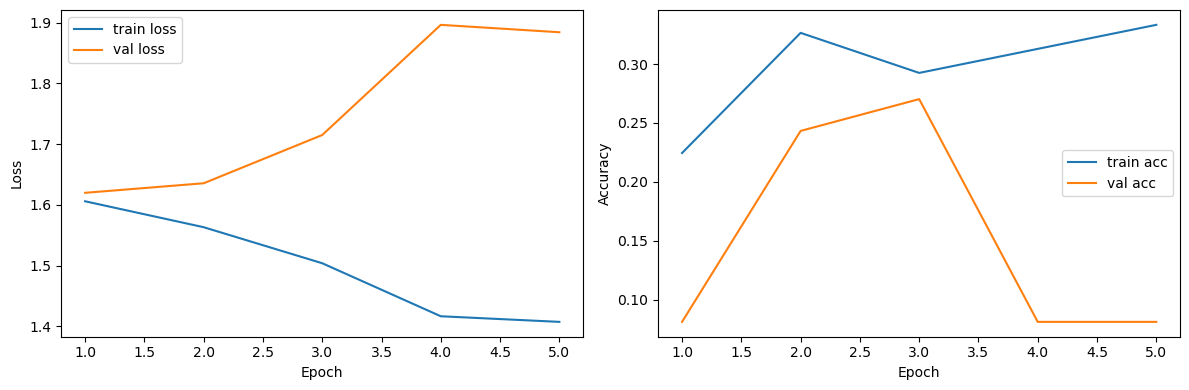

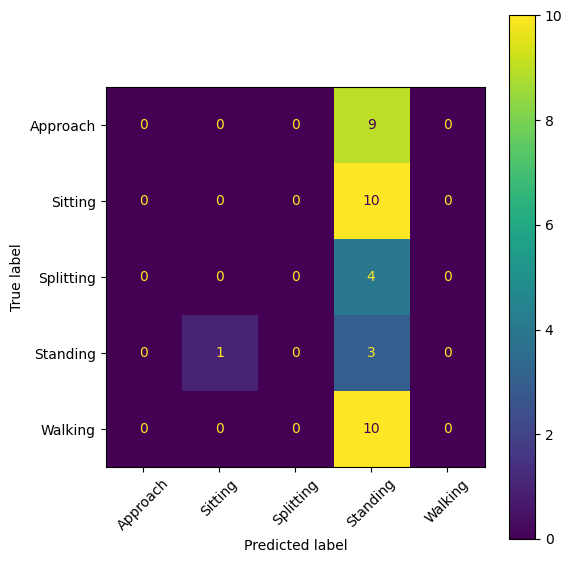

Saved training_curves.png and confusion_matrix.png in outputs


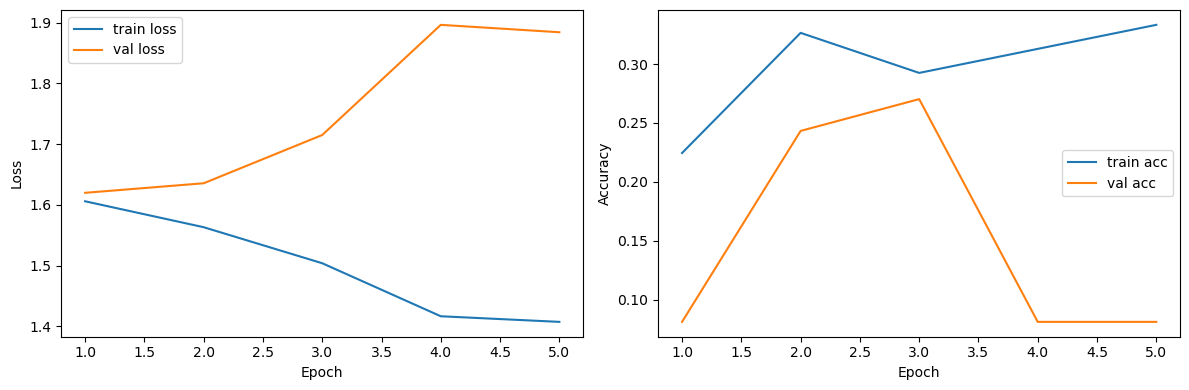

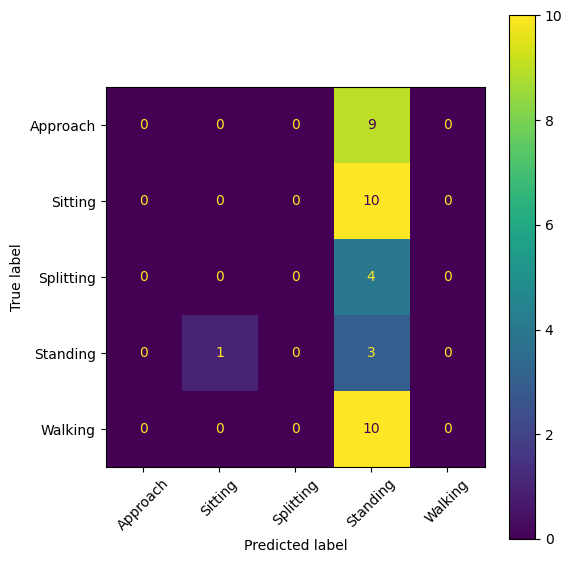

In [36]:
# Diagnostic cell: controlled train/validation run, plots, and confusion matrix
import random
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Settings
SEED = 42
EPOCHS = 5
BATCH_SIZE = 8
LR = 5e-4
VAL_SPLIT = 0.2
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

# Safety check
if not TORCH_AVAILABLE:
    print('Torch not available — skipping diagnostic run.')
else:
    # Fix seeds
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Build indices
    N = len(ds)
    indices = list(range(N))
    random.shuffle(indices)
    split = int(N * (1 - VAL_SPLIT))
    train_idx = indices[:split]
    val_idx = indices[split:]

    print(f'N samples: {N}, train: {len(train_idx)}, val: {len(val_idx)}')

    # Create torch datasets
    def make_torch_dataset_from_indices(indices_list):
        samples = [ (ds.samples[i][0], ds.labels.index(ds.samples[i][1])) for i in indices_list ]
        return TorchRangeDataset(samples)

    train_td = make_torch_dataset_from_indices(train_idx)
    val_td = make_torch_dataset_from_indices(val_idx)

    def collate(batch):
        seqs = np.stack([b[0] for b in batch], axis=0)  # B,T,H,W
        seqs = torch.from_numpy(seqs).float()
        labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
        return seqs, labels

    train_loader = torch.utils.data.DataLoader(train_td, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    val_loader = torch.utils.data.DataLoader(val_td, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CNNLSTM(n_classes=len(ds.get_label_names())).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                running_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
                all_preds.extend(preds.cpu().numpy().tolist())
                all_targets.extend(yb.cpu().numpy().tolist())
        val_loss = running_loss / total if total>0 else 0.0
        val_acc = correct / total if total>0 else 0.0
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{EPOCHS}: train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}')

    # Plot curves
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ax[0].plot(range(1,EPOCHS+1), train_losses, label='train loss')
    ax[0].plot(range(1,EPOCHS+1), val_losses, label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[1].plot(range(1,EPOCHS+1), train_accs, label='train acc')
    ax[1].plot(range(1,EPOCHS+1), val_accs, label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'training_curves.png')
    display(fig)

    # Confusion matrix on last validation predictions
    if len(all_targets) > 0:
        cm = confusion_matrix(all_targets, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ds.get_label_names())
        fig2, ax2 = plt.subplots(figsize=(6,6))
        disp.plot(ax=ax2, xticks_rotation=45)
        plt.tight_layout()
        fig2.savefig(OUT_DIR / 'confusion_matrix.png')
        display(fig2)
        print('Saved training_curves.png and confusion_matrix.png in', OUT_DIR)
    else:
        print('No validation samples to compute confusion matrix.')

Class counts (label_index:name:count):
0 Approach 37
1 Sitting 37
2 Splitting 37
3 Standing 35
4 Walking 38
Stratified split -> train 147 val 37
[BALANCED] Epoch 1/8: train_loss=1.6121, train_acc=0.218, val_loss=1.6096, val_acc=0.324
[BALANCED] Epoch 1/8: train_loss=1.6121, train_acc=0.218, val_loss=1.6096, val_acc=0.324
[BALANCED] Epoch 2/8: train_loss=1.6003, train_acc=0.279, val_loss=1.6122, val_acc=0.189
[BALANCED] Epoch 2/8: train_loss=1.6003, train_acc=0.279, val_loss=1.6122, val_acc=0.189
[BALANCED] Epoch 3/8: train_loss=1.5049, train_acc=0.361, val_loss=1.6914, val_acc=0.189
[BALANCED] Epoch 3/8: train_loss=1.5049, train_acc=0.361, val_loss=1.6914, val_acc=0.189
[BALANCED] Epoch 4/8: train_loss=1.2898, train_acc=0.415, val_loss=1.9821, val_acc=0.189
[BALANCED] Epoch 4/8: train_loss=1.2898, train_acc=0.415, val_loss=1.9821, val_acc=0.189
[BALANCED] Epoch 5/8: train_loss=1.3499, train_acc=0.299, val_loss=1.7664, val_acc=0.189
[BALANCED] Epoch 5/8: train_loss=1.3499, train_acc=0.2

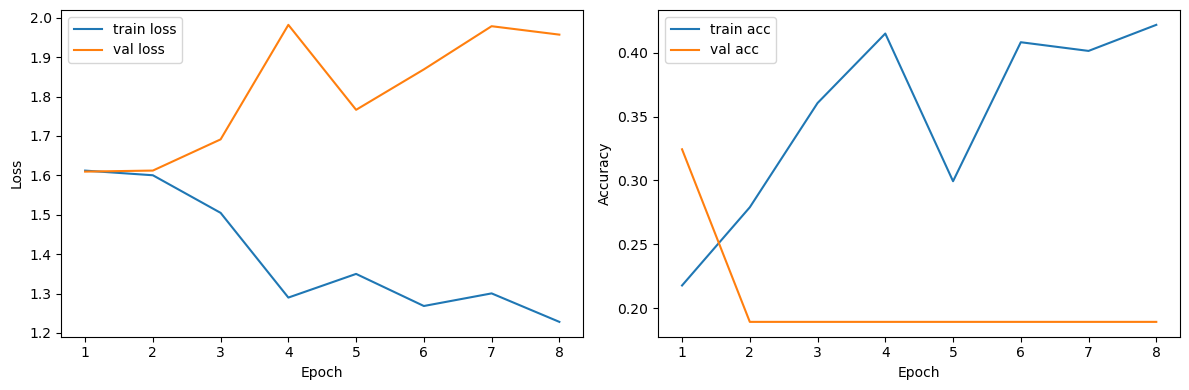

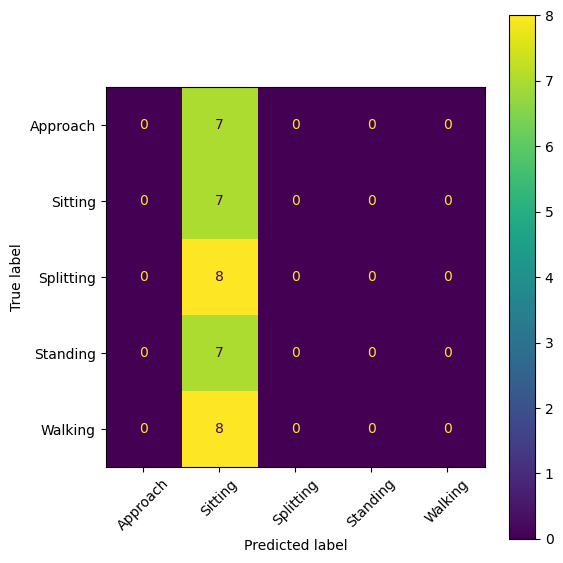

Saved balanced plots in outputs


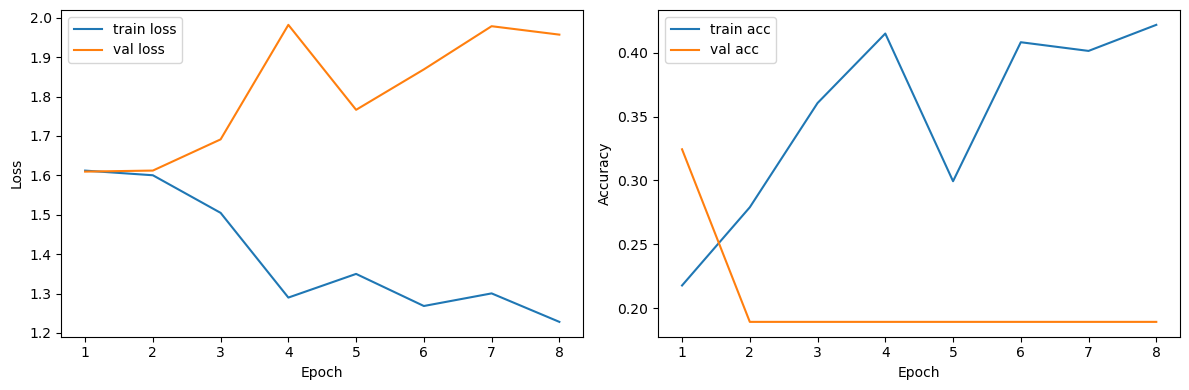

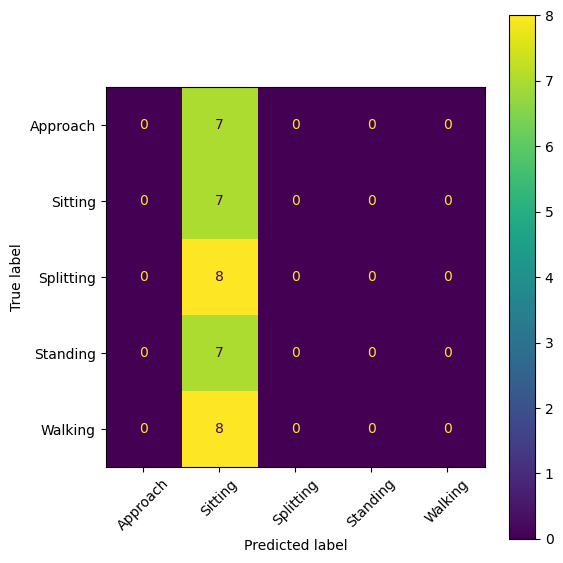

In [37]:
# Follow-up diagnostic: class balance, stratified split, weighted sampler + class-weighted loss
from collections import Counter
from sklearn.model_selection import train_test_split
import torch

if not TORCH_AVAILABLE:
    print('Torch not available — skipping balanced diagnostics.')
else:
    # compute class counts
    label_names = ds.get_label_names()
    labels_all = [label_names.index(s[1]) for s in ds.samples]
    counts = Counter(labels_all)
    print('Class counts (label_index:name:count):')
    for idx, cnt in sorted(counts.items()):
        print(idx, label_names[idx], cnt)

    # stratified split
    indices = list(range(len(ds)))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=labels_all)
    print(f'Stratified split -> train {len(train_idx)} val {len(val_idx)}')

    # build sample weights for WeightedRandomSampler
    train_labels = [labels_all[i] for i in train_idx]
    class_sample_count = np.array([counts[i] for i in sorted(counts.keys())])
    # inverse freq per class
    class_weights = {cls: 1.0 / count for cls, count in counts.items()}
    sample_weights = np.array([class_weights[lbl] for lbl in train_labels], dtype=np.float32)
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # class weights for loss (aligned by label index order)
    weight_tensor = torch.tensor([class_weights.get(i,1.0) for i in range(len(label_names))], dtype=torch.float32).to(device)

    # datasets/loaders
    train_samples = [ (ds.samples[i][0], ds.labels.index(ds.samples[i][1])) for i in train_idx ]
    val_samples   = [ (ds.samples[i][0], ds.labels.index(ds.samples[i][1])) for i in val_idx ]
    train_td = TorchRangeDataset(train_samples)
    val_td = TorchRangeDataset(val_samples)

    train_loader = torch.utils.data.DataLoader(train_td, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate)
    val_loader = torch.utils.data.DataLoader(val_td, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

    # reinitialize model
    model = CNNLSTM(n_classes=len(label_names)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)

    EPOCHS2 = 8
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(EPOCHS2):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        train_loss = running_loss / total if total>0 else 0.0
        train_acc = correct / total if total>0 else 0.0
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # val
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                running_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
                all_preds.extend(preds.cpu().numpy().tolist())
                all_targets.extend(yb.cpu().numpy().tolist())
        val_loss = running_loss / total if total>0 else 0.0
        val_acc = correct / total if total>0 else 0.0
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'[BALANCED] Epoch {epoch+1}/{EPOCHS2}: train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}')

    # plot
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ax[0].plot(range(1,EPOCHS2+1), train_losses, label='train loss')
    ax[0].plot(range(1,EPOCHS2+1), val_losses, label='val loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[1].plot(range(1,EPOCHS2+1), train_accs, label='train acc')
    ax[1].plot(range(1,EPOCHS2+1), val_accs, label='val acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'balanced_training_curves.png')
    display(fig)

    # confusion
    if len(all_targets)>0:
        cm = confusion_matrix(all_targets, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        fig2, ax2 = plt.subplots(figsize=(6,6))
        disp.plot(ax=ax2, xticks_rotation=45)
        plt.tight_layout()
        fig2.savefig(OUT_DIR / 'balanced_confusion_matrix.png')
        display(fig2)
        print('Saved balanced plots in', OUT_DIR)
    else:
        print('No val samples to compute confusion matrix in balanced run.')

Building grouped sequences (may take a few seconds)
Files with sequences found: 5
Total sequence samples: 184
Train files: 4 Val files: 1
Train samples: 147 Val samples: 37
Global train mean/std: 2482.820556640625 1706.998292015625
Normalized train/val samples
Files with sequences found: 5
Total sequence samples: 184
Train files: 4 Val files: 1
Train samples: 147 Val samples: 37
Global train mean/std: 2482.820556640625 1706.998292015625
Normalized train/val samples
[FILE-SPLIT] Epoch 1/10: train_acc=0.327, val_acc=0.000, train_loss=1.6073, val_loss=1.6282
[FILE-SPLIT] Epoch 2/10: train_acc=0.327, val_acc=0.000, train_loss=1.5850, val_loss=1.7066
[FILE-SPLIT] Epoch 3/10: train_acc=0.401, val_acc=0.000, train_loss=1.5580, val_loss=1.8269
[FILE-SPLIT] Epoch 4/10: train_acc=0.422, val_acc=0.000, train_loss=1.5269, val_loss=2.0726
[FILE-SPLIT] Epoch 5/10: train_acc=0.395, val_acc=0.000, train_loss=1.4713, val_loss=2.5324
[FILE-SPLIT] Epoch 6/10: train_acc=0.442, val_acc=0.000, train_loss=1.

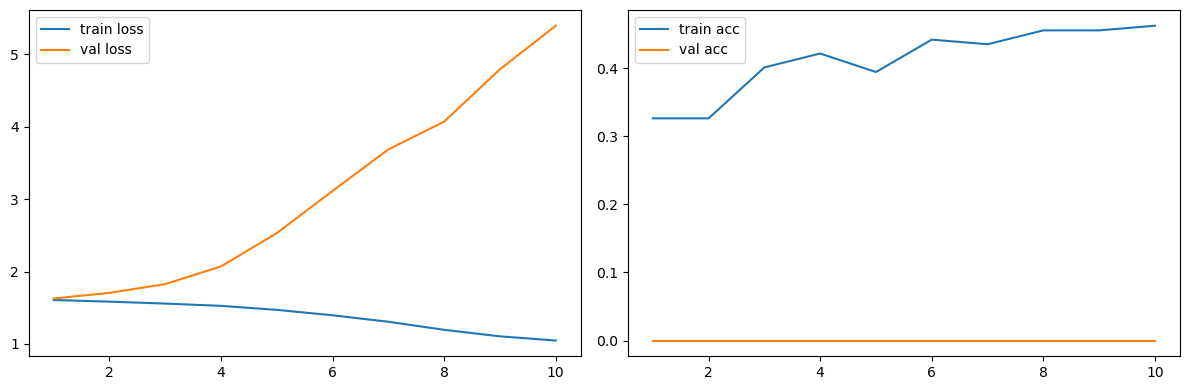

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (5).

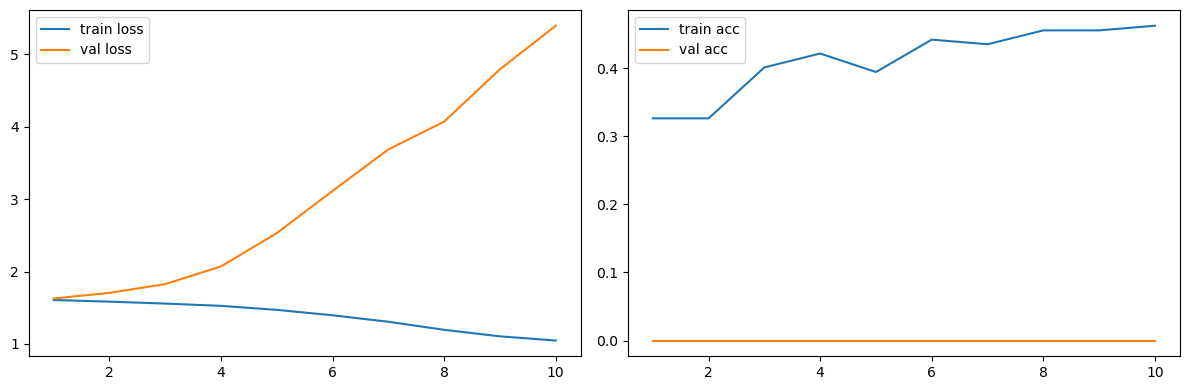

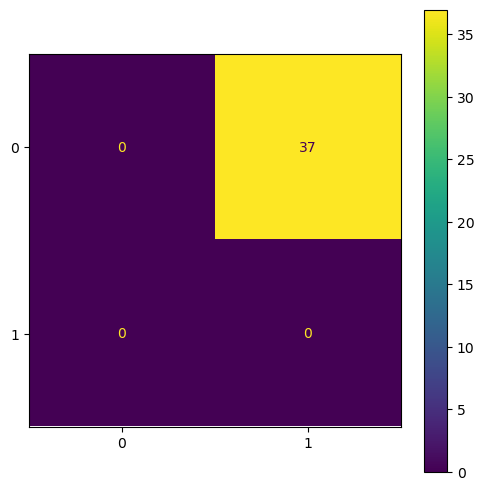

In [ ]:
# Preprocessing + file-level split + training with dataset-level normalization
from sklearn.metrics import classification_report
from collections import Counter

def build_sequences_grouped_by_file(root_dir, seq_len=8, stride=2, max_per_file=1000):
    root = Path(root_dir)
    groups = []  # (file_path, label_name, list_of_seqs)
    for activity_dir in sorted(root.iterdir()):
        if not activity_dir.is_dir():
            continue
        files = [p for p in activity_dir.glob('*.csv') if 'range' in p.name.lower() or 'doppler' in p.name.lower()]
        for f in files:
            try:
                df = pd.read_csv(f)
            except Exception:
                df = pd.read_table(f)
            heatmaps = []
            if set(('frame_number','range_bin','doppler_bin','signal_strength')).issubset(df.columns):
                long_hms = load_heatmaps_from_longform(df, max_frames=max_per_file)
                if long_hms is not None and len(long_hms)>0:
                    heatmaps = [hm.astype(np.float32) for hm in long_hms]
            else:
                for _, row in df.iterrows():
                    hm = parse_heatmap_from_df_row(row)
                    if hm is not None:
                        heatmaps.append(hm.astype(np.float32))
                        if len(heatmaps) >= max_per_file:
                            break
            # build sequences from heatmaps for this file
            seqs = []
            if len(heatmaps) >= seq_len:
                for start in range(0, len(heatmaps) - seq_len + 1, stride):
                    seq = np.stack(heatmaps[start:start+seq_len], axis=0)
                    seqs.append(seq)
            if seqs:
                groups.append((f, activity_dir.name, seqs))
    return groups

print('Building grouped sequences (may take a few seconds)')
groups = build_sequences_grouped_by_file(DATASET_ROOT, seq_len=8, stride=2)
print('Files with sequences found:', len(groups))

# flatten to sample-level but keep source file mapping
samples = []  # (file_path, seq, label)
for f,label,seqs in groups:
    for s in seqs:
        samples.append((f, s, label))
print('Total sequence samples:', len(samples))

# file-level stratified split: split files by label when possible
file_labels = [lbl for (_,lbl,_) in groups]
file_paths = [fp for (fp,_,_) in groups]
label_counts = Counter(file_labels)
min_count = min(label_counts.values()) if label_counts else 0

# If files per class < 2 for some class, fall back to a sample-level stratified split
perform_file_level = (min_count >= 2)
if perform_file_level:
    print('Performing file-level stratified split')
    train_files, val_files = train_test_split(file_paths, test_size=0.2, random_state=SEED, stratify=file_labels)
    # build train/val sample lists by file membership
    train_samples = []
    val_samples = []
    label_to_index = {name: i for i, name in enumerate(ds.get_label_names())}
    for f,s,label in samples:
        if f in train_files:
            train_samples.append((s, label_to_index[label]))
        elif f in val_files:
            val_samples.append((s, label_to_index[label]))
else:
    print('Not enough files per class for file-level stratify; falling back to sample-level stratified split')
    # sample-level stratified split: split sequences but stratify by label
    sample_seqs = [s for (_,s,_) in samples]
    sample_lbls = [ds.get_label_names().index(lbl) for (_,_,lbl) in samples]
    idx_train, idx_val = train_test_split(np.arange(len(sample_seqs)), test_size=0.2, random_state=SEED, stratify=sample_lbls)
    train_samples = [(sample_seqs[i], sample_lbls[i]) for i in idx_train]
    val_samples = [(sample_seqs[i], sample_lbls[i]) for i in idx_val]

print('Train samples:', len(train_samples), 'Val samples:', len(val_samples))

# compute dataset-level mean/std on train set
if len(train_samples) == 0:
    raise RuntimeError('No train samples found after splitting. Aborting.')
all_train_frames = np.concatenate([s for s,_ in train_samples], axis=0)  # concatenates along time axis
train_mean = float(all_train_frames.mean())
train_std = float(all_train_frames.std()) + 1e-6
print('Global train mean/std:', train_mean, train_std)

# normalization function
def normalize_seq(seq):
    return (seq - train_mean) / train_std

# normalize samples in-place (create normalized lists)
train_samples_norm = [(normalize_seq(s), lbl) for s,lbl in train_samples]
val_samples_norm   = [(normalize_seq(s), lbl) for s,lbl in val_samples]

print('Normalized train/val samples')

# Create torch datasets and loaders
train_td = TorchRangeDataset(train_samples_norm)
val_td = TorchRangeDataset(val_samples_norm)
train_loader = torch.utils.data.DataLoader(train_td, batch_size=8, shuffle=True, collate_fn=collate)
val_loader = torch.utils.data.DataLoader(val_td, batch_size=8, shuffle=False, collate_fn=collate)

# Reinit model and training config
model = CNNLSTM(n_classes=len(ds.get_label_names())).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 10
train_losses, val_losses, train_accs, val_accs = [],[],[],[]
all_preds, all_targs = None, None

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    train_losses.append(running_loss/total if total>0 else 0.0)
    train_accs.append(correct/total if total>0 else 0.0)

    # val
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    preds_list = []
    targs_list = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            preds_list.extend(preds.cpu().numpy().tolist())
            targs_list.extend(yb.cpu().numpy().tolist())
    val_losses.append(running_loss/total if total>0 else 0.0)
    val_accs.append(correct/total if total>0 else 0.0)
    all_preds = preds_list
    all_targs = targs_list
    print(f'[FILE/SAMPLE-SPLIT] Epoch {epoch+1}/{EPOCHS}: train_acc={train_accs[-1]:.3f}, val_acc={val_accs[-1]:.3f}, train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

# plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(range(1,EPOCHS+1), train_losses, label='train loss')
ax[0].plot(range(1,EPOCHS+1), val_losses, label='val loss')
ax[0].legend()
ax[1].plot(range(1,EPOCHS+1), train_accs, label='train acc')
ax[1].plot(range(1,EPOCHS+1), val_accs, label='val acc')
ax[1].legend()
plt.tight_layout()
fig.savefig(OUT_DIR / 'file_sample_split_curves.png')
display(fig)

# Robust confusion plotting: only include labels present in val set
if all_targs is not None and len(all_targs)>0:
    unique_lbls = sorted(set(all_targs))
    cm = confusion_matrix(all_targs, all_preds, labels=unique_lbls)
    display_labels = [ds.get_label_names()[i] for i in unique_lbls]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    fig2, ax2 = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax2, xticks_rotation=45)
    plt.tight_layout()
    fig2.savefig(OUT_DIR / 'file_sample_split_confusion.png')
    display(fig2)
    print('Classification report:')
    print(classification_report(all_targs, all_preds, target_names=[ds.get_label_names()[i] for i in unique_lbls], digits=3))
    print('Saved plots in', OUT_DIR)
else:
    print('No validation targets to evaluate.')